# Analysis of Concepts

In [1]:
import json
import pandas as pd

# requires the data from Zenodo
with open("data/divers1m_json/rich/divers1m.json", "r") as f:
    data = json.load(f)
    
df = pd.DataFrame.from_dict(data["info"], orient="index")
df["dvi"] = df.apply(lambda row: not (row.version in row.filename), axis=1)


## Missing Values

In [2]:
def get_nan_info(df, columns):
    n = len(df)
    for col in columns:
        if col.startswith("matched_"):
            n_empty = len(df[df[col].apply(len) == 0])
        else:
            n_empty = df[col].isna().sum()
        print(f"{col}: {n_empty:,} missing ({n_empty / n * 100:.2f}% of total {n})")
        
columns = [
    "tempo",
    "matched_instruments_groups",
    "matched_concepts",
    "matched_segments",
    "release_styles",
    "release_genres",
]

print("\nNaN info for full dataset")
get_nan_info(df, columns)

print("\nNaN info for DVI dataset")
get_nan_info(df[df.dvi], columns)



NaN info for full dataset
tempo: 69,417 missing (5.58% of total 1244810)
matched_instruments_groups: 763,629 missing (61.35% of total 1244810)
matched_concepts: 329,353 missing (26.46% of total 1244810)
matched_segments: 1,168,302 missing (93.85% of total 1244810)
release_styles: 804,611 missing (64.64% of total 1244810)
release_genres: 804,611 missing (64.64% of total 1244810)

NaN info for DVI dataset
tempo: 198 missing (0.04% of total 444821)
matched_instruments_groups: 291,038 missing (65.43% of total 444821)
matched_concepts: 3,548 missing (0.80% of total 444821)
matched_segments: 434,973 missing (97.79% of total 444821)
release_styles: 4,622 missing (1.04% of total 444821)
release_genres: 4,622 missing (1.04% of total 444821)


## Value Distributions

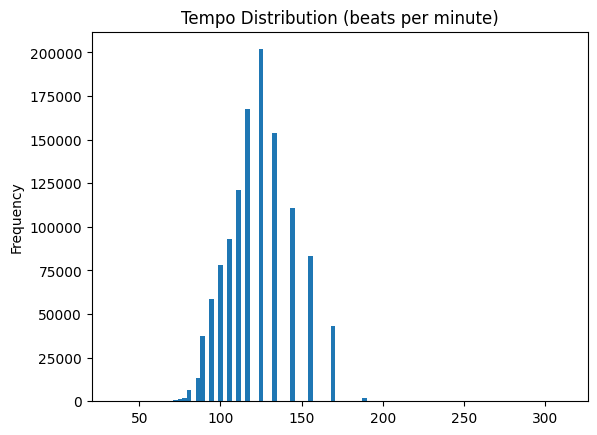

In [3]:
import matplotlib.pyplot as plt

df.tempo.plot(kind="hist", bins=100, title="Tempo Distribution (beats per minute)")
plt.show()


In [13]:
def parse_matched_dict(d):
    if isinstance(d, dict):
        return list({k for sub in d.values() for k in sub.keys()})
    return []

df["Concepts"] = df.matched_concepts.apply(parse_matched_dict)
df["Instruments / Groups"] = df.matched_instruments_groups.apply(parse_matched_dict)
df["Data Source"] = df.apply(lambda row: "Discogs" if row.dvi else "YouTube", axis=1)


Saved PDF: figures/matched_concepts.pdf


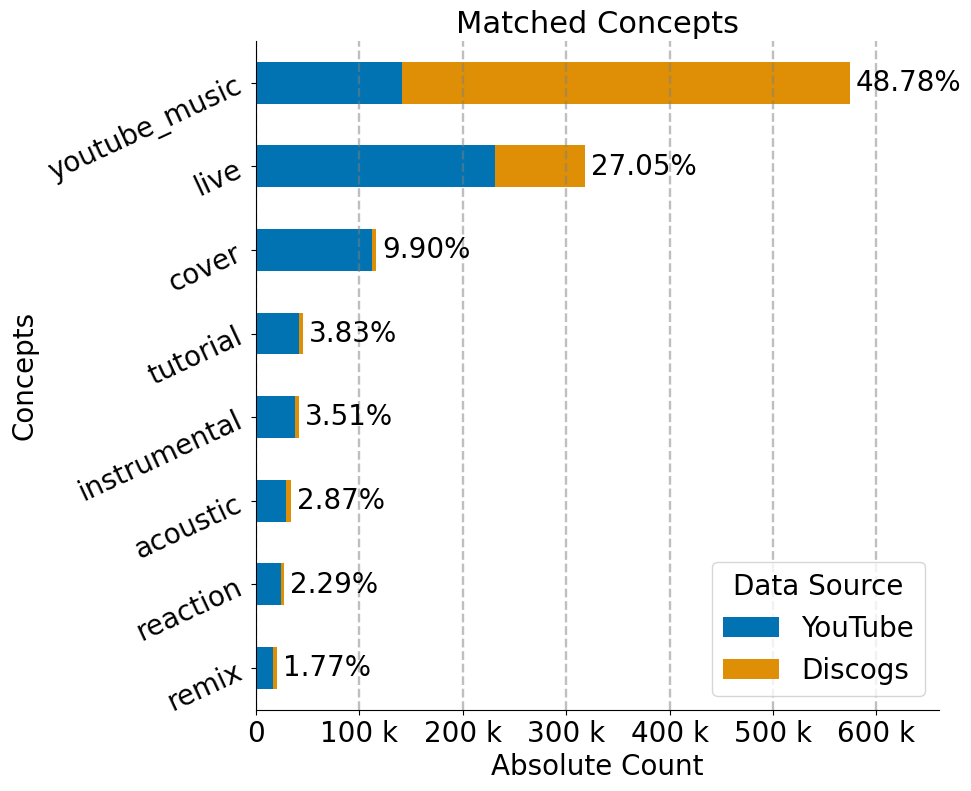

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import seaborn as sns

sns.set_palette("colorblind")


def plot_string_counts_barh(df, label_name, top_n=None, out_file=None, hue=None, stacked=True):
    """
    Plot a horizontal bar chart of value counts (absolute and relative) from a Series of lists,
    optionally split (hued) by another column. 
    Percentages and vertical lines are always computed on the overall counts.
    """
    # Explode lists into rows
    exploded = df.explode(label_name)

    if hue is None:
        counts = exploded[label_name].value_counts()
    else:
        counts = exploded.groupby([label_name, hue]).size().unstack(fill_value=0)
        # Reverse column order for stacked bars and legend
        counts = counts[counts.columns[::-1]]

        # Colorblind-friendly palette
        palette = sns.color_palette("colorblind", n_colors=len(counts.columns))
        color_map = {col: palette[i] for i, col in enumerate(counts.columns)}
        colors = [color_map[col] for col in counts.columns]
    # Top-N filtering
    if top_n:
        if hue is None:
            counts = counts.head(top_n)
        else:
            top_labels = counts.sum(axis=1).sort_values(ascending=False).head(top_n).index
            counts = counts.loc[top_labels]

    # Global counts for percentages & vlines
    overall_counts = counts if hue is None else counts.sum(axis=1)
    relative = overall_counts / overall_counts.sum()

    # Plot
    plt.rcParams.update({'font.size': 20})
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.grid(True, axis='x', linestyle='--', alpha=0.7)

    if hue is None:
        bars = ax.barh(overall_counts.index, overall_counts.values, color='skyblue')
    else:
        counts.plot(kind="barh", stacked=stacked, ax=ax, color=colors)

    # Add vertical lines at xticks
    for xtick in ax.get_xticks():
        ax.axvline(x=xtick, color='gray', linestyle='--', linewidth=1.7, alpha=0.5)

    # Add percentages (based on overall counts)
    max_val = overall_counts.max()
    for i, (abs_val, rel_val) in enumerate(zip(overall_counts.values, relative.values)):
        ax.text(abs_val + max_val * 0.01, i, f"{rel_val:.2%}", va='center', fontsize=20)

    # Formatting
    ax.set_xlim(0, max_val * 1.15)
    ax.xaxis.set_major_formatter(EngFormatter(unit=''))
    ax.set_xlabel("Absolute Count", fontsize=20)
    ax.invert_yaxis()
    plt.yticks(rotation=25)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, format='pdf', bbox_inches='tight')
        print(f"Saved PDF: {out_file}")

    ax.set_title(f"Matched {label_name}", fontsize=22)
    plt.show()

plot_string_counts_barh(df, "Concepts", top_n=20, out_file="figures/matched_concepts.pdf", hue="Data Source")


Saved PDF: figures/matched_instruments_groups.pdf


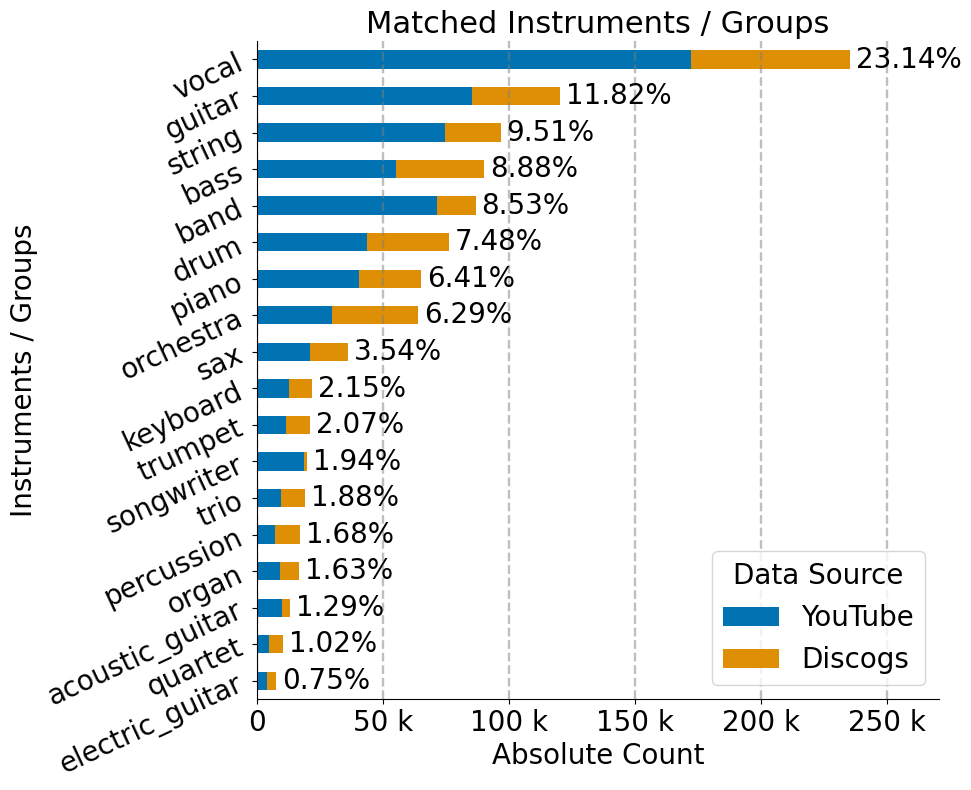

In [27]:
plot_string_counts_barh(df, "Instruments / Groups", top_n=20, out_file="figures/matched_instruments_groups.pdf", hue="Data Source")
